# Probabilistic intraday cross zonal capacity on the IEEE 30 bus grid

**Question.** How much power can be exchanged between two bidding zones without violating any thermal limit, in the N state and after any single outage (N-1)? How does that capacity change when the day ahead forecast is updated intraday, and how large a reliability margin (TRM) does forecast uncertainty require?

**Method.** DC load flow sensitivities (PTDF, LODF), generation shift keys (GSK), CNEC selection with a 5 % zonal PTDF threshold, TTC = base case exchange + maximum shift, NTC = TTC - TRM with a Monte Carlo TRM. Every analytical result is cross checked against pandapower's own load flow solver, including full N-1 re-simulation and an AC load flow at the capacity limit.

In [1]:
import sys, copy, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, networkx as nx
import logging
logging.getLogger("pandapower").setLevel(logging.ERROR)
import pandapower as pp
from capacity import *
from scenarios import *
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False})
FIG = "../figures/"


## 1. Network, bidding zones and contingency list
Zone 1 of the IEEE case is treated as **CH**, zones 2 and 3 as the neighbour **NB**. A 50 MW wind farm is connected in NB at bus 10 (bus numbers are 1-based, as in the IEEE case). The contingency list contains every single line outage that does not island part of the grid.

In [2]:
net = build_network()
units0 = conventional_units(net)
ptdf, lodf, rate = dc_sensitivities(net)
cont = credible_contingencies(net, ptdf)
tie = tie_lines(net)
radial = sorted(set(range(len(net.line))) - set(cont))
print("Buses per zone:", net.bus.bz.value_counts().to_dict())
print("Tie lines CH-NB:", [line_label(net, l) for l in tie[0]])
print(f"Credible N-1 contingencies: {len(cont)} of {len(net.line)} lines")
print("Excluded (radial, outage islands a bus):", [line_label(net, l) for l in radial])
pd.DataFrame({"bus": units0["bus"] + 1, "zone": units0["zone"], "P base (MW)": units0["p"].round(1), "Pmax (MW)": units0["pmax"]})

Buses per zone: {'NB': 19, 'CH': 11}
Tie lines CH-NB: ['6-10', '9-10', '4-12', '28-27']
Credible N-1 contingencies: 38 of 41 lines
Excluded (radial, outage islands a bus): ['9-11', '12-13', '25-26']


,bus,zone,P base (MW),Pmax (MW)
0,1,CH,23.5,80.0
1,2,CH,61.0,80.0
2,22,NB,21.6,50.0
3,27,NB,26.9,55.0
4,23,NB,19.2,30.0
5,13,NB,37.0,40.0


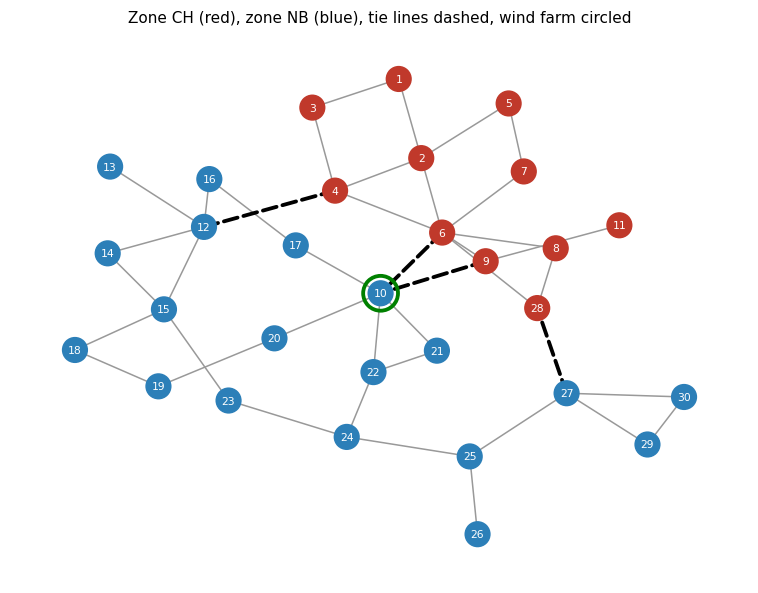

In [3]:
def draw_grid(highlight=(), fname=None):
    G = nx.Graph()
    for l, r in net.line.iterrows():
        G.add_edge(int(r.from_bus), int(r.to_bus), idx=l)
    pos = nx.kamada_kawai_layout(G)
    fig, ax = plt.subplots(figsize=(7, 5.5))
    col = ["#c0392b" if z == ZONE_A else "#2c7fb8" for z in net.bus.bz]
    ties, hl = set(tie[0]), set(highlight)
    kind = lambda e: "hl" if G.edges[e]["idx"] in hl else ("tie" if G.edges[e]["idx"] in ties else "int")
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[e for e in G.edges if kind(e) == "int"], edge_color="#999")
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[e for e in G.edges if kind(e) == "tie"], edge_color="k", width=2.5, style="--")
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[e for e in G.edges if kind(e) == "hl"], edge_color="#f39c12", width=5)
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=col, node_size=260)
    nx.draw_networkx_labels(G, pos, ax=ax, labels={b: b + 1 for b in G.nodes}, font_size=7, font_color="w")
    nx.draw_networkx_nodes(G, pos, ax=ax, nodelist=[WIND_BUS], node_color="none", edgecolors="green", linewidths=2.5, node_size=520)
    t = "Zone CH (red), zone NB (blue), tie lines dashed, wind farm circled"
    ax.set_title(t + ("\nbinding CNECs in orange" if hl else ""), fontsize=10)
    ax.axis("off"); plt.tight_layout()
    if fname: plt.savefig(FIG + fname, dpi=150)
    plt.show()

draw_grid()

## 2. Validation of the DC sensitivities
Before using PTDF and LODF for anything, check them against pandapower's DC load flow:
* base flows computed as PTDF x injections must equal the DC load flow;
* post outage flows computed with LODF must equal a DC load flow re-run with the line switched off, for all 38 contingencies.

PTDF vs DC load flow, max error: 4.6e-14 MW
LODF vs 38 re-simulated outages (1520 flows), max error: 1.2e-13 MW


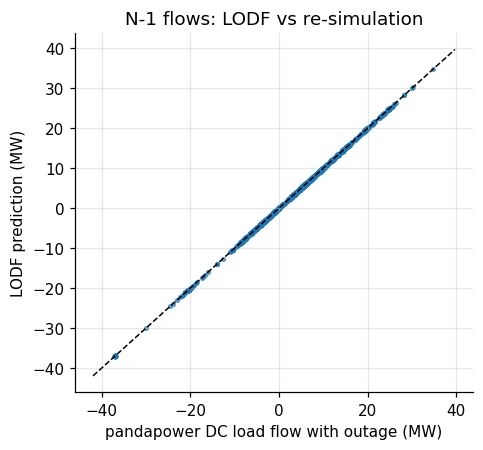

In [4]:
P0 = nodal_injection(net, units0["p"], units0["bus"])
f_ptdf = ptdf @ P0
pp.rundcpp(net, numba=False)
err_ptdf = np.abs(f_ptdf - net.res_line.p_from_mw.values).max()

pred, sim = [], []
for k in cont:
    n = copy.deepcopy(net); n.line.loc[k, "in_service"] = False; pp.rundcpp(n, numba=False)
    m = np.arange(len(net.line)) != k
    pred.append((f_ptdf + lodf[:, k] * f_ptdf[k])[m]); sim.append(n.res_line.p_from_mw.values[m])
pred, sim = np.concatenate(pred), np.concatenate(sim)
print(f"PTDF vs DC load flow, max error: {err_ptdf:.1e} MW")
print(f"LODF vs {len(cont)} re-simulated outages ({len(pred)} flows), max error: {np.abs(pred - sim).max():.1e} MW")

fig, ax = plt.subplots(figsize=(4.5, 4.2))
ax.scatter(sim, pred, s=6, alpha=0.6); lim = [sim.min() - 5, sim.max() + 5]
ax.plot(lim, lim, "k--", lw=1); ax.set_xlabel("pandapower DC load flow with outage (MW)"); ax.set_ylabel("LODF prediction (MW)")
ax.set_title("N-1 flows: LODF vs re-simulation"); plt.tight_layout(); plt.savefig(FIG + "02_lodf_validation.png", dpi=150); plt.show()

## 3. Zonal PTDF
With pro rata GSKs, the zonal PTDF of an element is the share of a 1 MW exchange CH -> NB that flows through it. A useful sanity check: the zonal PTDFs of the tie lines must add up to exactly 1, because every exchanged MW has to cross the border.

In [5]:
z0 = zonal_ptdf(ptdf, gsk(units0, ZONE_A, len(net.bus)), gsk(units0, ZONE_B, len(net.bus)))
print("Sum of tie line zonal PTDFs:", round(float(np.sum(z0[tie[0]] * tie[1])), 6))
top = np.argsort(-np.abs(z0))[:8]
pd.DataFrame({"line": [line_label(net, l) for l in top], "zonal PTDF": z0[top].round(3), "rating (MW)": rate[top],
              "CNEC (|zPTDF| >= 5 %)": np.abs(z0[top]) >= CNEC_THRESHOLD})

Sum of tie line zonal PTDFs: 1.0


,line,zonal PTDF,rating (MW),CNEC (|zPTDF| >= 5 %)
0,4-12,0.385,65.0,True
1,12-13,0.353,65.0,True
2,2-6,0.319,65.0,True
3,2-4,0.302,65.0,True
4,28-27,0.247,65.0,True
5,3-4,0.235,130.0,True
6,1-3,0.235,130.0,True
7,9-10,0.234,65.0,True


## 4. Capacity for one hour (12:00, day ahead forecast)
First check that the base case is N-1 secure; otherwise there is no capacity to give and redispatch would be needed. Then compute the maximum shift in each direction and the binding constraint (critical network element and contingency, CNEC/CO).

In [6]:
H = 12
r = capacity_hour(net, units0, ptdf, lodf, rate, cont, tie, LOAD_PROFILE[H], WIND_DA[H], NP_SCHED[H])
nN, nN1 = security_check(r["f0"], rate, lodf, cont)
print(f"Base case: max loading N = {nN:.0%}, max loading N-1 = {nN1:.0%}  ->  secure: {nN1 <= 1}")
print(f"Base case exchange CH->NB: {r['bce']:.1f} MW (scheduled {NP_SCHED[H]:.0f} MW)")
lbl = lambda a: f"{line_label(net, a[0])} after outage of {line_label(net, a[1])}" if a[1] >= 0 else f"{line_label(net, a[0])} in N state"
print(f"TTC CH->NB: {r['ttc_export']:.1f} MW, binding: {lbl(r['bind_export'])}")
print(f"TTC NB->CH: {r['ttc_import']:.1f} MW, binding: {lbl(r['bind_import'])}")

Base case: max loading N = 79%, max loading N-1 = 93%  ->  secure: True
Base case exchange CH->NB: 10.0 MW (scheduled 10 MW)
TTC CH->NB: 32.1 MW, binding: 6-8 after outage of 6-28
TTC NB->CH: 11.9 MW, binding: 23-24 after outage of 15-23


## 5. Independent N-1 verification at the capacity limit
The analytical result is only credible if the physics confirms it. Apply the computed shift to the pandapower model (moving generation with the GSKs), then re-run a DC load flow **for every outage** and check that:
* the binding element sits at exactly 100 % after the binding outage;
* no element exceeds 100 % in any other N-1 state;
* 1 MW more exchange causes a violation.

Finally run a full **AC** load flow at the same point to see what the DC approximation leaves out (reactive power, losses, voltages).

In [7]:
def shifted_units(r, de):
    u = balance_zone(r["units"], ZONE_A, +de)
    return balance_zone(u, ZONE_B, -de)

def resimulate_n1(u, lf, wind, ac=False):
    base = set_dispatch(net, u, lf, lf, wind)
    worst = (0, None, None)
    for k in [-1] + list(cont):
        n = copy.deepcopy(base)
        if k >= 0: n.line.loc[k, "in_service"] = False
        if ac:
            pp.runpp(n, numba=False)
            load = n.res_line.loading_percent.values / 100   # current based
        else:
            pp.rundcpp(n, numba=False)
            load = np.abs(n.res_line.p_from_mw.values) / rate
        if k >= 0: load[k] = 0
        l = int(np.argmax(load))
        if load[l] > worst[0]: worst = (load[l], l, k)
    return worst

lf, w = LOAD_PROFILE[H], WIND_DA[H]
de = r["de_export"]
for label, shift in [("at TTC", de), ("TTC + 1 MW", de + 1)]:
    ld, l, k = resimulate_n1(shifted_units(r, shift), lf, w)
    print(f"DC re-simulation {label:11s}: worst loading {ld:.2%} on {line_label(net, l)} after outage of {line_label(net, k)}")
ld0, l, k = resimulate_n1(shifted_units(r, 0), lf, w, ac=True)
print(f"AC re-simulation base case : worst loading {ld0:.2%} on {line_label(net, l)} after outage of {line_label(net, k)}")
ld, l, k = resimulate_n1(shifted_units(r, de), lf, w, ac=True)
print(f"AC re-simulation at DC TTC : worst loading {ld:.2%} on {line_label(net, l)} after outage of {line_label(net, k)}")

# AC validated capacity: largest shift for which the full AC N-1 analysis stays within limits
lo, hi = 0.0, de
for _ in range(14):
    mid = 0.5 * (lo + hi)
    lo, hi = (mid, hi) if resimulate_n1(shifted_units(r, mid), lf, w, ac=True)[0] <= 1 else (lo, mid)
ac_ttc = r["bce"] + lo
print(f"TTC CH->NB: DC {r['ttc_export']:.1f} MW  vs  AC validated {ac_ttc:.1f} MW  (DC optimistic by {r['ttc_export'] - ac_ttc:.1f} MW)")


DC re-simulation at TTC     : worst loading 100.00% on 6-8 after outage of 6-28


DC re-simulation TTC + 1 MW : worst loading 100.67% on 6-8 after outage of 6-28


AC re-simulation base case : worst loading 98.63% on 8-28 after outage of 6-8


AC re-simulation at DC TTC : worst loading 100.75% on 6-28 after outage of 6-8


TTC CH->NB: DC 32.1 MW  vs  AC validated 31.2 MW  (DC optimistic by 1.0 MW)


**Reading.** The DC re-simulation reproduces the analytical limit exactly: the binding element reaches 100 % after the binding outage, nothing else is overloaded, and one more MW creates a violation. The capacity is therefore fully supported by the N-1 analysis.

The AC check adds what DC ignores: reactive power flows, losses and voltages. At the DC limit the AC analysis finds a slightly higher loading on a *different* element, because reactive flow adds to the current. The AC validated capacity is found by bisection on the full AC N-1 analysis. This is why TSOs validate DC based capacity with AC security analysis.

## 6. Day ahead vs intraday capacity over 24 hours
The day ahead forecast (D-1) is updated intraday (ID): the weather front arrives about three hours earlier, so wind in NB is higher from late morning. Capacity is recalculated with the updated base case.

All 48 base cases N-1 secure: True
Largest intraday change of TTC CH->NB: 9.2 MW at 13:00

Binding constraints CH->NB (hours):
stage  cnec_exp                
DA     6-28 after outage of 6-8    14 h
       6-8 after outage of 6-28    10 h
ID     6-28 after outage of 6-8    14 h
       6-8 after outage of 6-28    10 h


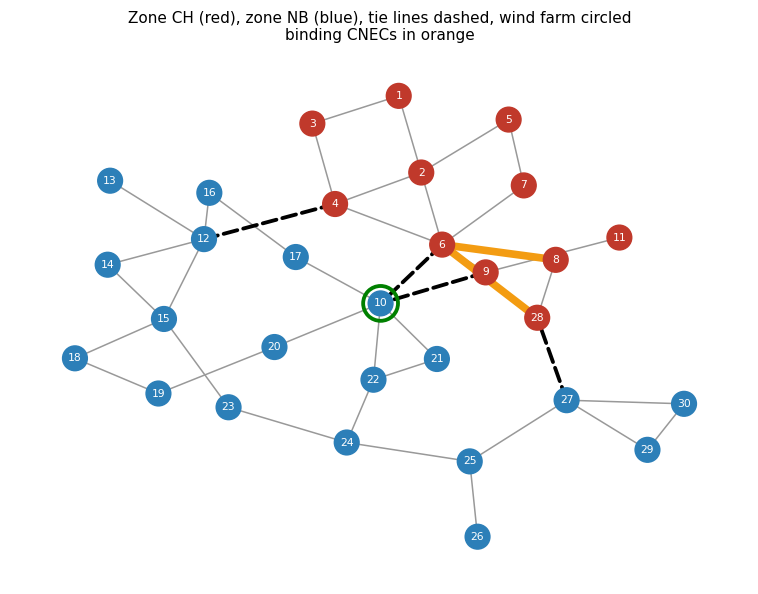

In [8]:
rows = []
for h in HOURS:
    for stage, W in [("DA", WIND_DA), ("ID", WIND_ID)]:
        rr = capacity_hour(net, units0, ptdf, lodf, rate, cont, tie, LOAD_PROFILE[h], W[h], NP_SCHED[h])
        nN, nN1 = security_check(rr["f0"], rate, lodf, cont)
        rows.append({"hour": h, "stage": stage, "wind": W[h], "bce": rr["bce"], "secure": nN1 <= 1 + 1e-9,
                     "ttc_exp": rr["ttc_export"], "ttc_imp": rr["ttc_import"],
                     "cnec_exp": lbl(rr["bind_export"]), "cnec_imp": lbl(rr["bind_import"]), "res": rr})
df = pd.DataFrame(rows)
print("All 48 base cases N-1 secure:", bool(df.secure.all()))
piv = df.pivot(index="hour", columns="stage", values="ttc_exp")
print(f"Largest intraday change of TTC CH->NB: {(piv.ID - piv.DA).abs().max():.1f} MW at {int((piv.ID - piv.DA).abs().idxmax())}:00")
print("\nBinding constraints CH->NB (hours):")
print(df.groupby(["stage", "cnec_exp"]).hour.apply(lambda x: f"{len(x)} h").to_string())
binding = {rr["bind_export"][0] for rr in df.res} | {rr["bind_export"][1] for rr in df.res}
draw_grid(highlight=binding, fname="01_network.png")

## 7. Probabilistic reliability margin (TRM)
Forecast errors of wind and load change the real flows. They are balanced by frequency containment reserves shared by both zones, so part of every error flows across the grid as an unscheduled flow. For each hour and stage, 1 000 Monte Carlo samples give the distribution of the remaining margin; the TRM is the reduction that is not exceeded with 95 % probability. Intraday forecasts are more accurate (smaller sigma), so the TRM shrinks and capacity is released.

In [9]:
trm = []
for i, row in df.iterrows():
    t_exp, t_imp, m_exp, m_imp = monte_carlo_trm(net, row.res, ptdf, lodf, rate, cont, LOAD_PROFILE[row.hour], row.stage, n_samples=1000, seed=int(row.hour))
    trm.append((t_exp, t_imp))
    if row.hour == H: df.loc[i, "samples"] = None; globals()["samples_" + row.stage] = (m_exp, row.res["de_export"])
df["trm_exp"], df["trm_imp"] = zip(*trm)
df["ntc_exp"], df["ntc_imp"] = df.ttc_exp - df.trm_exp, df.ttc_imp - df.trm_imp
summary = df.groupby("stage")[["ttc_exp", "trm_exp", "ntc_exp", "ttc_imp", "trm_imp", "ntc_imp"]].mean().round(1)
summary.columns = ["TTC CH->NB", "TRM CH->NB", "NTC CH->NB", "TTC NB->CH", "TRM NB->CH", "NTC NB->CH"]
print("Daily average (MW):"); display(summary)
for d, lab in [("exp", "CH->NB"), ("imp", "NB->CH")]:
    dttc = df[df.stage == "ID"]["ttc_" + d].values - df[df.stage == "DA"]["ttc_" + d].values
    dtrm = df[df.stage == "DA"]["trm_" + d].values - df[df.stage == "ID"]["trm_" + d].values
    print(f"{lab}: intraday change of NTC = {dttc.mean():+.1f} MW from the updated base case (TTC) {dtrm.mean():+.1f} MW from the smaller TRM = {dttc.mean() + dtrm.mean():+.1f} MW on average")

Daily average (MW):


,TTC CH->NB,TRM CH->NB,NTC CH->NB,TTC NB->CH,TRM NB->CH,NTC NB->CH
stage,,,,,,
DA,37.7,4.6,33.1,29.1,5.4,23.8
ID,35.1,2.1,33.0,33.5,2.2,31.2


CH->NB: intraday change of NTC = -2.7 MW from the updated base case (TTC) +2.5 MW from the smaller TRM = -0.2 MW on average
NB->CH: intraday change of NTC = +4.4 MW from the updated base case (TTC) +3.1 MW from the smaller TRM = +7.5 MW on average


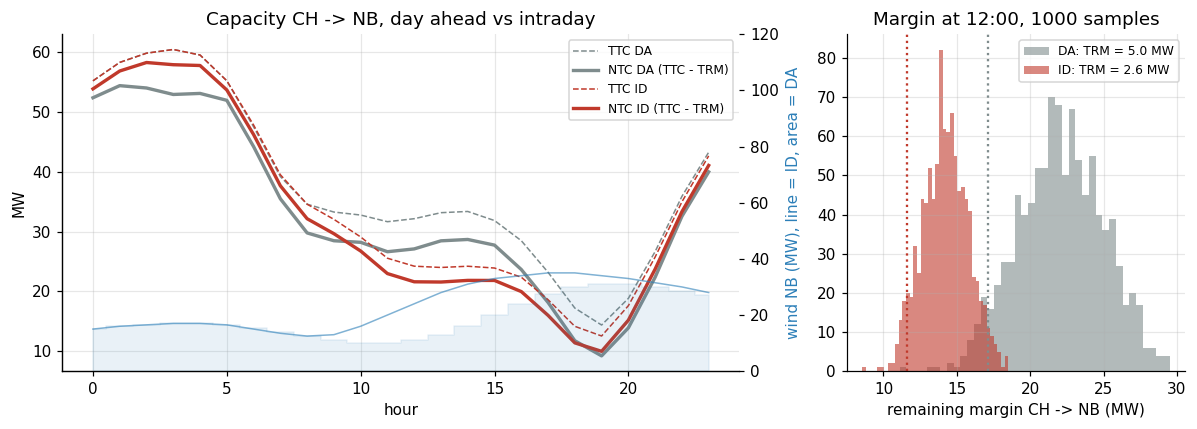

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw={"width_ratios": [2, 1]})
for stage, c in [("DA", "#7f8c8d"), ("ID", "#c0392b")]:
    d = df[df.stage == stage]
    ax[0].plot(d.hour, d.ttc_exp, color=c, lw=1, ls="--", label=f"TTC {stage}")
    ax[0].plot(d.hour, d.ntc_exp, color=c, lw=2.2, label=f"NTC {stage} (TTC - TRM)")
ax2 = ax[0].twinx(); ax2.fill_between(HOURS, WIND_DA, color="#2c7fb8", alpha=0.10, step="mid"); ax2.plot(HOURS, WIND_ID, color="#2c7fb8", lw=1, alpha=0.6)
ax2.set_ylabel("wind NB (MW), line = ID, area = DA", color="#2c7fb8"); ax2.grid(False); ax2.set_ylim(0, 120)
ax[0].set_xlabel("hour"); ax[0].set_ylabel("MW"); ax[0].set_title("Capacity CH -> NB, day ahead vs intraday"); ax[0].legend(loc="upper right", fontsize=8)
for stage, c in [("DA", "#7f8c8d"), ("ID", "#c0392b")]:
    m, de = globals()["samples_" + stage]
    ax[1].hist(m, bins=40, alpha=0.6, color=c, label=f"{stage}: TRM = {de - np.quantile(m, 0.05):.1f} MW")
    ax[1].axvline(np.quantile(m, 0.05), color=c, ls=":")
ax[1].set_title(f"Margin at {H}:00, 1000 samples"); ax[1].set_xlabel("remaining margin CH -> NB (MW)"); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIG + "03_capacity_da_vs_id.png", dpi=150); plt.show()

## 8. Conclusions and limitations
* The capacity limits obtained with PTDF/LODF are reproduced exactly by re-simulating every N-1 state, so each capacity value is backed by the security analysis and the binding CNEC/CO is identified explicitly.
* Recalculating intraday with an updated forecast changes both the base case flows (TTC) and the uncertainty (TRM). Both effects must be considered when adjusting import and export capacity intraday.
* A probabilistic TRM links the margin to the actual forecast accuracy of each stage instead of a fixed percentage.

**Limitations.** DC approximation (validated against AC at the limit, but not replacing it); IEEE test grid with its original ratings used as MW limits; same rating for N and N-1 (no temporary emergency ratings); pro rata GSKs; illustrative profiles and Gaussian, uncorrelated forecast errors; no remedial actions (topology changes, phase shifting transformers, redispatch), which in practice increase capacity.